# (노트) 단순선형회귀 (1) 

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [데이터과학]

In [152]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.experimental.numpy as tnp

In [153]:
tnp.random.randn(10)

<tf.Tensor: shape=(10,), dtype=float64, numpy=
array([-0.75011622, -0.64386623,  1.07255104,  0.92120417, -0.42603143,
       -0.91344533, -0.25962951, -2.18773535,  1.29042271, -0.41956407])>

In [154]:
tf.random.set_seed(43052)
epsilon=tf.random.normal([10])
epsilon

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([ 0.9983651 , -0.8457241 ,  1.090825  ,  0.85255873, -0.7729972 ,
       -1.724309  , -0.5929508 ,  1.1765009 ,  0.42130336,  0.76988286],
      dtype=float32)>

In [155]:
x=tf.constant([20.1, 22.2, 22.7, 23.3, 24.4, 25.1, 26.2, 27.3, 28.4, 30.4])
x

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([20.1, 22.2, 22.7, 23.3, 24.4, 25.1, 26.2, 27.3, 28.4, 30.4],
      dtype=float32)>

$$ {\bf y} \approx 10.2 + 2.2 {\bf X} $$ 

In [156]:
y=10.2 + 2.2*x + epsilon
y

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([55.418365, 58.194283, 61.230827, 62.312557, 63.107002, 63.69569 ,
       67.247055, 71.4365  , 73.1013  , 77.84988 ], dtype=float32)>

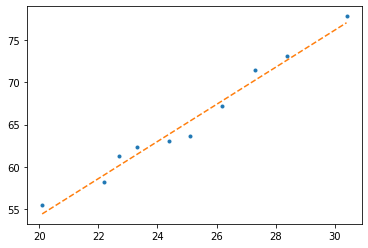

In [158]:
plt.plot(x,y,'.')
plt.plot(x,10.2 + 2.2*x ,'--')

목표: 파란색점 $\to$ 주황색선 추론 

데이터를 보니까 x와 y는 선형의 관계인것 처럼 보인다. 

In [159]:
tnp.transpose(tnp.concatenate([[x],[y]],0))

<tf.Tensor: shape=(10, 2), dtype=float32, numpy=
array([[20.1     , 55.418365],
       [22.2     , 58.194283],
       [22.7     , 61.230827],
       [23.3     , 62.312557],
       [24.4     , 63.107002],
       [25.1     , 63.69569 ],
       [26.2     , 67.247055],
       [27.3     , 71.4365  ],
       [28.4     , 73.1013  ],
       [30.4     , 77.84988 ]], dtype=float32)>

적당히 왼쪽숫자에서 $\times 2+15$ 정도하면 오른쪽 숫자가 나오는것 같음

즉 모든 $i=1,2,3,\dots, 10$에 대하여 $y_i \approx \beta_0 + \beta_1 x_i $ 라는 관계로 표현할 수 있겠음.. 

물론 딱 $y_i=\beta_0+\beta_1 x_i$를 만족하는 $(\beta_0,\beta_1)$ 값은 없지만 어느정도 비슷하게는 맞출 수 있겠음. 즉 약간의 `오차`는 있겠으나 어느정도 비슷하게는 맞출수 있다. 

좋은 추정치를 고르는 방법 

- 후보1: $(\beta_0,\beta_1)=(15,2)$ 
- 후보2: $(\beta_0,\beta_1)=(10,2)$ 

후보1을 $i=1,2$에 넣고 관찰하여보자. 

In [160]:
20.1*2 + 15, 55.418365 # i=1

(55.2, 55.418365)

In [161]:
22.2*2 + 15, 58.194283 # i=2

(59.4, 58.194283)

후보2를 $i=1,2$에 넣고 관찰하여보자. 

In [162]:
20.1*2 + 10, 55.418365 # i=1

(50.2, 55.418365)

In [163]:
22.2*2 + 10, 58.194283 # i=2

(54.4, 58.194283)

$i=1,2$에서는 후보1이 더 잘맞는것 같다. 

$i=1,2,\dots,10$에서 후보1이 좋은지 후보2가 좋은지 종합적으로 비교하려면? 

후보1, 2에 대하여 $\sum_{i=1}^{10}(y_i-\beta_0-\beta_1x_i)^2$의 값을 비교해보자. 

In [164]:
sum1=0
for i in range(10):
    sum1=sum1+(y[i]-15-2*x[i])**2

In [165]:
sum2=0
for i in range(10):
    sum2=sum2+(y[i]-10-2*x[i])**2

In [166]:
sum1,sum2

(<tf.Tensor: shape=(), dtype=float32, numpy=14.734169>,
 <tf.Tensor: shape=(), dtype=float32, numpy=298.6688>)

후보1이 종합적으로 더 좋음 

이런식으로 무한대의 후보를 찾을수는 없음. $\to$ 좀더 체계적으로 찾아보자. 

$\sum_{i=1}^{10}(y_i-\beta_0-\beta_1x_i)^2$ 

를 풀면 $\beta_0$, $\beta_1$에 대한 2차식일것임 

즉 아래와 같은 형태일것임 

$\sum_{i=1}^{10}(y_i-\beta_0-\beta_1x_i)^2=a_1\beta_0^2+a_2\beta_1^2+a_3\beta_0+a_4\beta_1+a_5$ 

여기에서 $a_1,a_2,\dots,a_5$는 계산할 수 있음.. 

결국 이차식의 최소값을 구하는 문제로 귀결되므로 아래를 연립하여 풀면된다. 

\begin{cases}
\frac{\partial}{\partial \beta_0} \sum_{i=1}^{10}(y_i-\beta_0-\beta_1x_i)^2 =0  \\ 
\frac{\partial}{\partial \beta_1} \sum_{i=1}^{10}(y_i-\beta_0-\beta_1x_i)^2 =0 
\end{cases}

정리하면 

\begin{cases}
\sum_{i=1}^{10}2(y_i-\beta_0-\beta_1x_i) =0  \\ 
\sum_{i=1}^{10}2x_i(y_i-\beta_0-\beta_1x_i) =0 
\end{cases}

풀면 아래와 같이 나온다. 

$$\hat{\beta}_0=\bar{y}-\hat{\beta}_1 \bar{x}$$ 

$$\hat{\beta}_1=\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}{\sum_{i=1}^n(x_i-\bar{x})^2}=\frac{S_{xy}}{S_{xx}}$$ 

따라서 최적의 선은 아래와 같이 구할 수 있음 

In [167]:
Sxx=sum((x-tnp.mean(x))**2)
Sxx

<tf.Tensor: shape=(), dtype=float32, numpy=87.84898>

In [168]:
Sxx=tnp.std(x)**2*10
Sxx

<tf.Tensor: shape=(), dtype=float32, numpy=87.84898>

In [169]:
Sxy=sum((y-tnp.mean(y))*(x-tnp.mean(x)))
Sxy

<tf.Tensor: shape=(), dtype=float32, numpy=194.64737>

In [170]:
beta1_estimated = Sxy/Sxx
beta1_estimated

<tf.Tensor: shape=(), dtype=float32, numpy=2.2157042>

In [171]:
beta0_estimated = tnp.mean(y)-tnp.mean(x)*beta1_estimated
beta0_estimated

<tf.Tensor: shape=(), dtype=float32, numpy=9.944588>

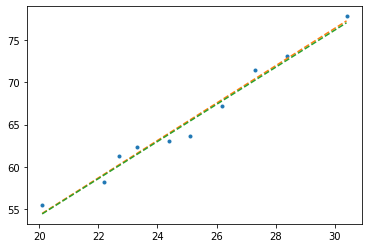

In [173]:
plt.plot(x,y,'.')
plt.plot(x,beta0_estimated+ beta1_estimated*x,'--')
plt.plot(x,10.2+ 2.2*x,'--')

- 샘플수가 커질수록 초록색선은 점점 주황색선으로 가까워진다. 

꽤 훌륭한 도구임 

그런데 약간의 단점이 존재 

(1) 공식이 조금 복잡함.. 

(2) 변수가 여러개일경우 확장이 어려움 

우리가 했던 논의를 매트릭스 버전으로 해보자. 

우리의 모형은 아래와 같다. 

$y_i=\beta_0 + \beta_1 x_i +\epsilon_i, \quad i=1,2,\dots, 10$


풀어서 쓰면 

$\begin{cases}
y_1 = \beta_0 +\beta_1 x_1 + \epsilon_1 \\ 
y_2 = \beta_0 +\beta_1 x_2 + \epsilon_2 \\ 
\dots \\ 
y_{10} = \beta_0 +\beta_1 x_{10} + \epsilon_{10} 
\end{cases}$

아래와 같이 쓸 수 있다. 

$\begin{bmatrix} 
y_1 \\ 
y_2 \\ 
\dots \\
y_{10} 
\end{bmatrix} 
= \begin{bmatrix} 
1 & x_1 \\ 
1 & x_2 \\ 
\dots & \dots \\
1 & x_{10} 
\end{bmatrix}\begin{bmatrix}\beta_0 \\ \beta_1 \end{bmatrix} + \begin{bmatrix} 
\epsilon_1 \\ 
\epsilon_2 \\ 
\dots \\
\epsilon_{10} 
\end{bmatrix} $

벡터와 매트릭스 형태로 정리하면 

${\bf y} = {\bf X} \boldsymbol{\beta} + \boldsymbol{\epsilon}$

우리가 최소화 하고싶은었던 식은 아래였다. 

$loss=\sum_{i=1}^{n} (y_i-\beta_0-\beta_1 x_i)^2$

이것역시 벡터표현으로 쓰면 아래와 같다. 

$loss=\sum_{i=1}^{n}(y_i-\beta_0-\beta_1 x_i)^2=({\bf y}-{\bf X}{\boldsymbol \beta})^\top({\bf y}-{\bf X}{\boldsymbol \beta}) $

풀어보면 

$loss={\bf y}^\top {\bf y} - {\bf y}^\top {\bf X}{\boldsymbol\beta} - {\boldsymbol\beta}^\top {\bf X}^\top {\bf y} + {\boldsymbol\beta}^\top {\bf X}^\top {\bf X} {\boldsymbol\beta}$ 

loss를 최소화하는 $\boldsymbol{\beta}$를 구해야하므로 loss를 $\boldsymbol{\beta}$로 미분한식을 0이라 놓고 풀면된다. 

$\frac{\partial}{\partial \boldsymbol{\beta}} loss = \frac{\partial}{\partial \boldsymbol{\beta}} {\bf y}^\top {\bf y} - \frac{\partial}{\partial \boldsymbol{\beta}} {\bf y}^\top {\bf X}{\boldsymbol\beta} - \frac{\partial}{\partial \boldsymbol{\beta}} {\boldsymbol\beta}^\top {\bf X}^\top {\bf y} + \frac{\partial}{\partial \boldsymbol{\beta}} {\boldsymbol\beta}^\top {\bf X}^\top {\bf X} {\boldsymbol\beta}$ 

$=0-{\bf X}^\top {\bf y} - {\bf X}^\top {\bf y} + 2{\bf X}^\top {\bf X} {\boldsymbol \beta}$ 

따라서 $\frac{\partial}{\partial \boldsymbol{\beta}} loss = 0$ 을 풀면 아래와 같다. 

$\boldsymbol{\hat{\beta}}=\bf (X^\top X)^{-1}X^\top y  $

In [147]:
from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()

In [148]:
X=tf.concat([[tf.constant([1.0]*10)],[x]],0).T
X

<tf.Tensor: shape=(10, 2), dtype=float32, numpy=
array([[ 1. , 20.1],
       [ 1. , 22.2],
       [ 1. , 22.7],
       [ 1. , 23.3],
       [ 1. , 24.4],
       [ 1. , 25.1],
       [ 1. , 26.2],
       [ 1. , 27.3],
       [ 1. , 28.4],
       [ 1. , 30.4]], dtype=float32)>

In [149]:
tf.linalg.inv(X.T @ X) @ X.T @ y

<tf.Tensor: shape=(2,), dtype=float64, numpy=array([9.94515277, 2.21567779])>

In [150]:
beta0_estimated,beta1_estimated

(<tf.Tensor: shape=(), dtype=float64, numpy=9.944573243234004>,
 <tf.Tensor: shape=(), dtype=float64, numpy=2.215704607783491>)

- 오차가 좀 크다..? 

텐서플로우가 좀 대충 계산함.. 신경쓰지마세요.. 

In [151]:
x=tnp.array([20.1, 22.2, 22.7, 23.3, 24.4, 25.1, 26.2, 27.3, 28.4, 30.4])
y=10.2 + 2.2*x + epsilon

In [122]:
beta1_estimated = sum((x-tnp.mean(x))*(y-tnp.mean(y)))/ sum((x-tnp.mean(x))*(x-tnp.mean(x)))
beta0_estimated = tnp.mean(y) - beta1_estimated* tnp.mean(x)

In [123]:
beta0_estimated,beta1_estimated

(<tf.Tensor: shape=(), dtype=float64, numpy=9.944573243234004>,
 <tf.Tensor: shape=(), dtype=float64, numpy=2.215704607783491>)

In [139]:
X=tnp.concatenate([[tnp.array([1.0]*10)],[x]],0).T
tf.linalg.inv(X.T @ X) @ X.T @ y

<tf.Tensor: shape=(2,), dtype=float64, numpy=array([9.94457324, 2.21570461])>